In [ ]:
# DAY 1

In [ ]:
from transformers import AutoTokenizer
import torch
import numpy as np
import joblib

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print(tokenizer.vocab_size)
print(tokenizer.model_max_length)

text = "This movie was absolutely amazing!"

tokens = tokenizer(text)
print(tokens)

input_ids = tokens['input_ids']
print(f'Количество токенов: {len(input_ids)}')

decoded = tokenizer.decode(input_ids)
print(f'Декодировано: {decoded}')


def tokenize_texts(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

texts = [
    "This movie was great!",
    "Terrible movie, waste of time."
]

tokens = tokenize_texts(texts)
print(f'Shape: {tokens["input_ids"].shape}')

print(f'Attention mask:\n{tokens["attention_mask"]}')

print(f'CLS token: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})')
print(f'SEP token: {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})')
print(f'PAD token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})')


single = tokenizer(text, return_tensors="pt")
print(f'Input IDs: {single["input_ids"]}')
print(f'Decoded: {tokenizer.decode(single["input_ids"][0])}')

def explain_tokenization(text, tokenizer):
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.convert_tokens_to_ids(tokens)

    print(f'Исходный текст: {text}')
    print(f'Токены: {tokens}')
    print(f'IDs: {ids}')
    print(f'Количество: {len(tokens)}')

explain_tokenization("Transformers are amazing!", tokenizer)


30522
512
{'input_ids': [101, 2023, 3185, 2001, 7078, 6429, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}
Количество токенов: 8
Декодировано: [CLS] this movie was absolutely amazing! [SEP]
Shape: torch.Size([2, 9])
Attention mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1]])
CLS token: [CLS] (ID: 101)
SEP token: [SEP] (ID: 102)
PAD token: [PAD] (ID: 0)
Input IDs: tensor([[ 101, 2023, 3185, 2001, 7078, 6429,  999,  102]])
Decoded: [CLS] this movie was absolutely amazing! [SEP]
Исходный текст: Transformers are amazing!
Токены: ['transformers', 'are', 'amazing', '!']
IDs: [19081, 2024, 6429, 999]
Количество: 4


In [ ]:
# DAY 2

In [ ]:
from transformers import AutoModel
model_name = "distilbert-base-uncased"
model = AutoModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
model.eval()

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [ ]:
print(model)

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [ ]:
text = "This movie was absolutely amazing!"
tokens = tokenizer(text, return_tensors="pt")

In [ ]:
with torch.no_grad():
  outputs = model(**tokens)

In [ ]:
print(type(outputs))
print(outputs.last_hidden_state.shape)


<class 'transformers.modeling_outputs.BaseModelOutput'>
torch.Size([1, 8, 768])


In [ ]:
cls_embedding = outputs.last_hidden_state[:,0,:]
print(f'CLS embedding shape: {cls_embedding.shape}')
print(f'CLS embedding: {cls_embedding[0][:5]}...')

CLS embedding shape: torch.Size([1, 768])
CLS embedding: tensor([ 0.0682, -0.0685,  0.1918,  0.0139, -0.0544])...


In [ ]:
def get_embeddings(texts, tokenizer, model, batch_size=32):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        tokens = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = model(**tokens)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

In [ ]:
texts = [
    "This movie was absolutely amazing!",
    "Terrible movie, waste of time.",
    "Pretty good, I liked it.",
    "Boring and too long."
]

In [ ]:
embeddings = get_embeddings(texts, tokenizer, model)
print(f'Embeddings shape: {embeddings.shape}')
print('Ожидается: (4, 768) для DistilBERT')

Embeddings shape: (4, 768)
Ожидается: (4, 768) для DistilBERT


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(text1, text2, tokenizer, model):
    emb = get_embeddings([text1, text2], tokenizer, model)
    sim = cosine_similarity(emb[0:1], emb[1:2])[0][0]
    return sim

In [ ]:
sim1 = similarity("Great movie!", "Amazing film!", tokenizer, model)
sim2 = similarity("Great movie!", "Terrible film!", tokenizer, model)

print(sim1)
print(sim2)

0.9954952
0.98384976


# DAY 3

In [ ]:
from transformers import AutoModel

model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True  # важно!
)
model.eval()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [ ]:
text = "The amazing movie won many awards"
tokens = tokenizer(text, return_tensors="pt")

In [ ]:
tokens

{'input_ids': tensor([[ 101, 1996, 6429, 3185, 2180, 2116, 2982,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [ ]:
with torch.no_grad():
    outputs = model(**tokens)

In [ ]:
print(type(outputs.attentions))
print(f'Количество слоёв: {len(outputs.attentions)}')
print(f'Форма attention для слоя 0: {outputs.attentions[0].shape}')

<class 'tuple'>
Количество слоёв: 6
Форма attention для слоя 0: torch.Size([1, 12, 8, 8])


In [ ]:
attention = outputs.attentions[0]  # первый слой
print(f'Attention shape: {attention.shape}')

# Для первого батча, первой головы
attn_single = attention[0, 0]  # [seq_len, seq_len]
print(f'Single head shape: {attn_single.shape}')

Attention shape: torch.Size([1, 12, 8, 8])
Single head shape: torch.Size([8, 8])


In [ ]:
pip install matplotlib seaborn

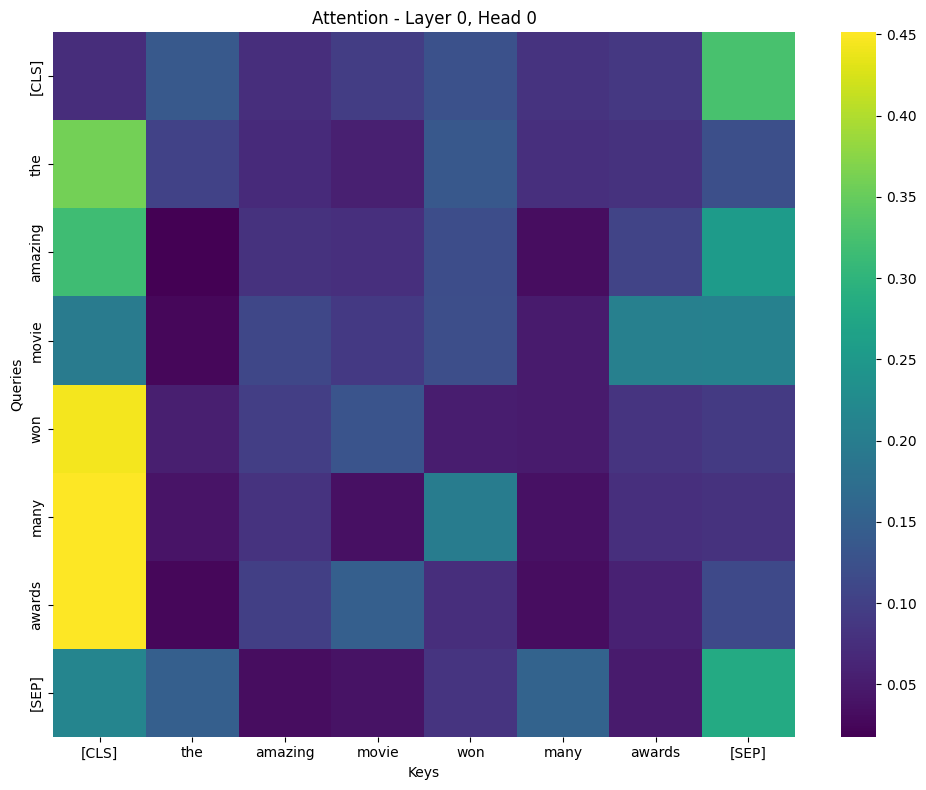

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_attention(tokens, attention, layer=0, head=0):
    """
    tokens: токенизированный текст
    attention: attention weights от модели
    layer: номер слоя для визуализации
    head: номер головы для визуализации
    """
    # Получаем attention матрицу
    attn = attention[layer][0, head]  # [seq_len, seq_len]

    # Получаем токены для подписей
    token_list = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])

    # Рисуем heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attn.cpu().numpy(),
        xticklabels=token_list,
        yticklabels=token_list,
        cmap='viridis',
        cbar=True
    )
    plt.title(f'Attention - Layer {layer}, Head {head}')
    plt.xlabel('Keys')
    plt.ylabel('Queries')
    plt.tight_layout()
    plt.savefig(f'attention_layer{layer}_head{head}.png')
    plt.show()

# Используйте:
visualize_attention(tokens, outputs.attentions, layer=0, head=0)

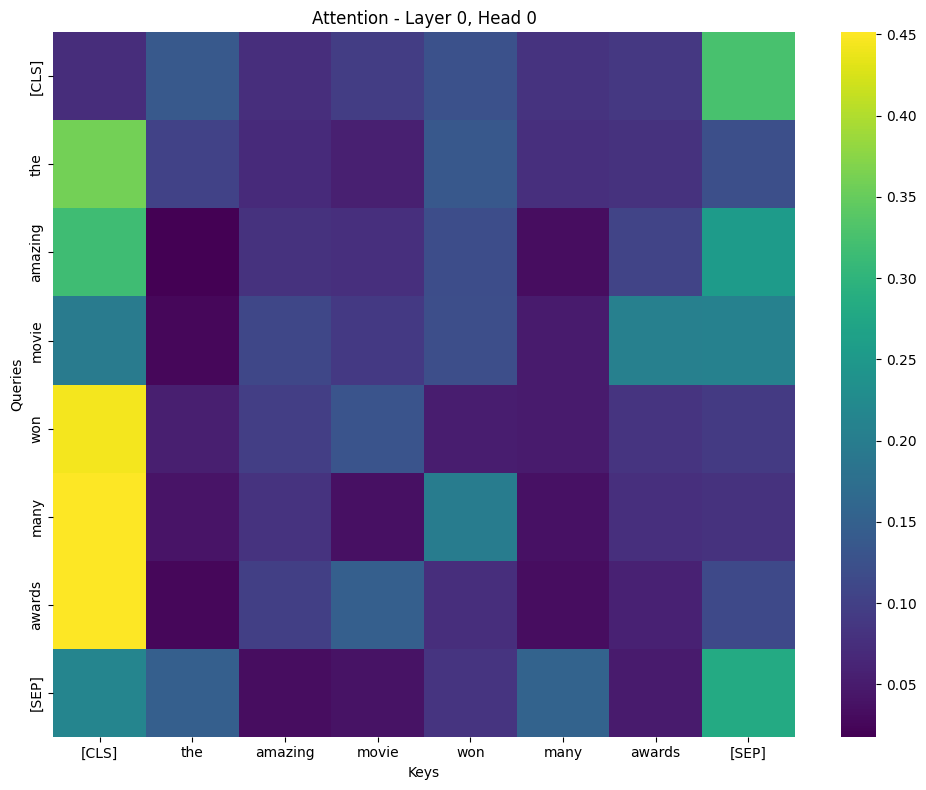

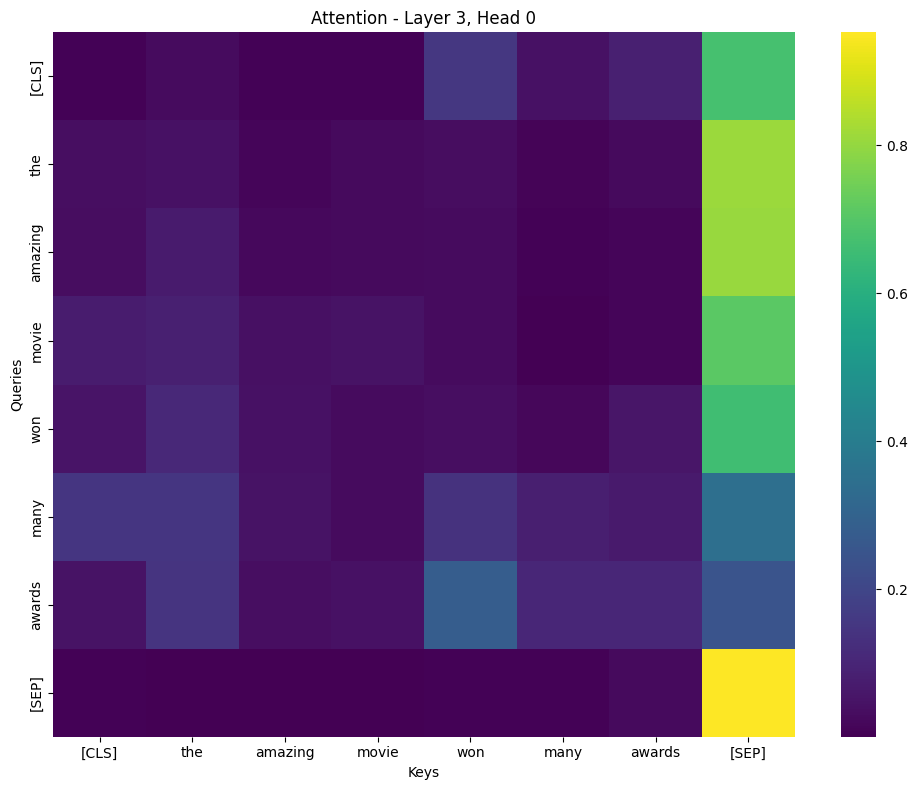

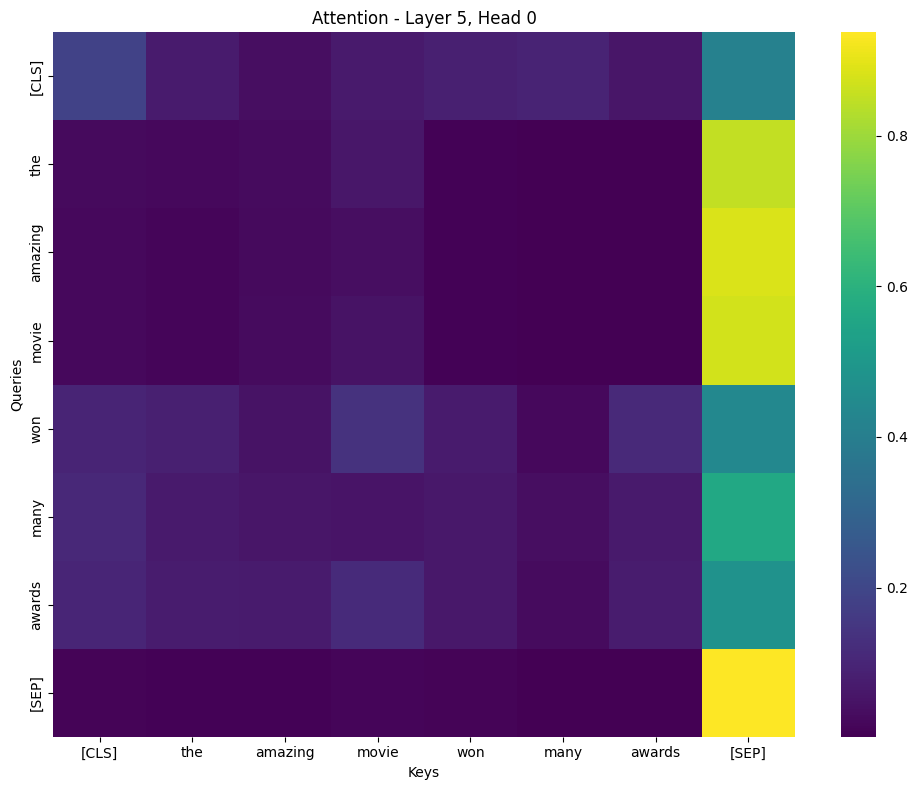

In [ ]:
# Первый слой
visualize_attention(tokens, outputs.attentions, layer=0, head=0)

# Средний слой
visualize_attention(tokens, outputs.attentions, layer=3, head=0)

# Последний слой
visualize_attention(tokens, outputs.attentions, layer=5, head=0)

и правда сфокусированно

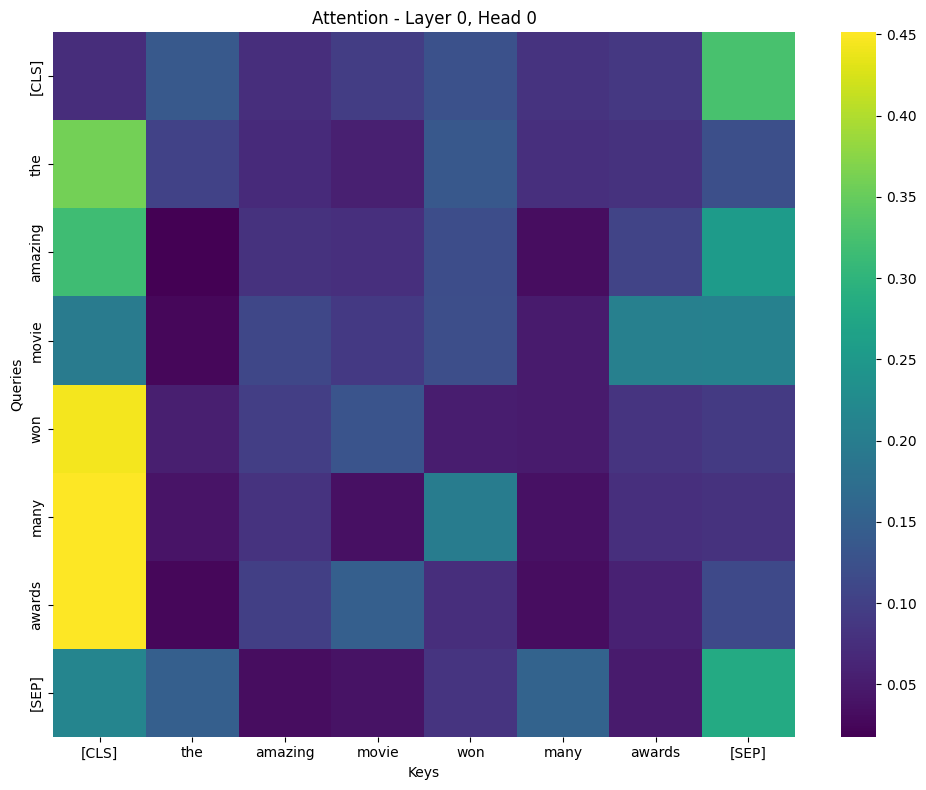

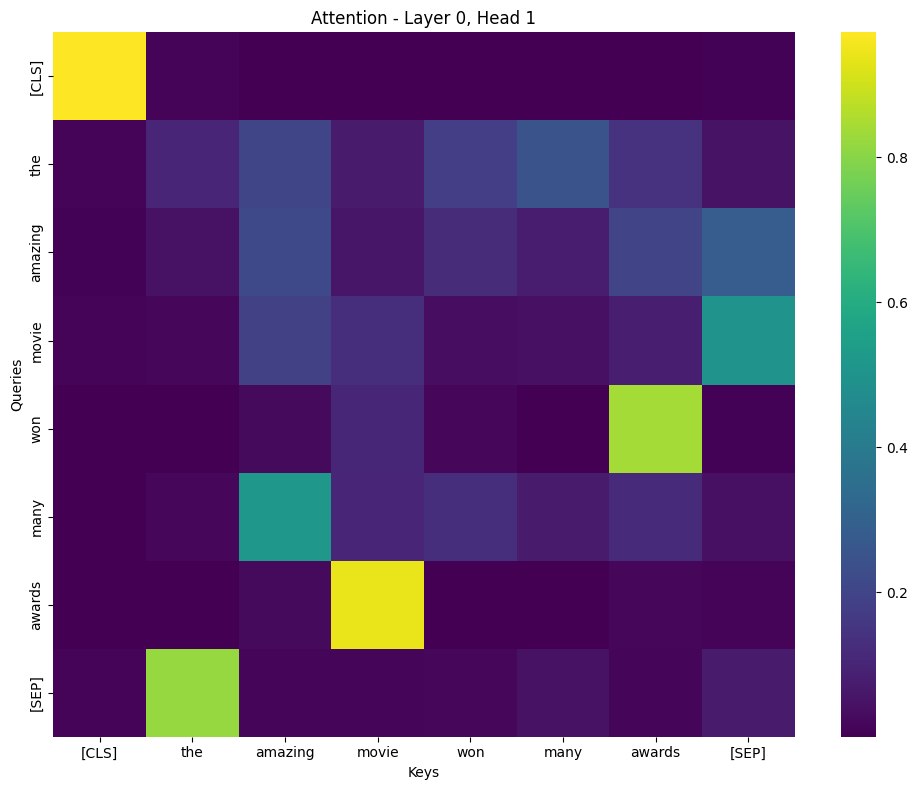

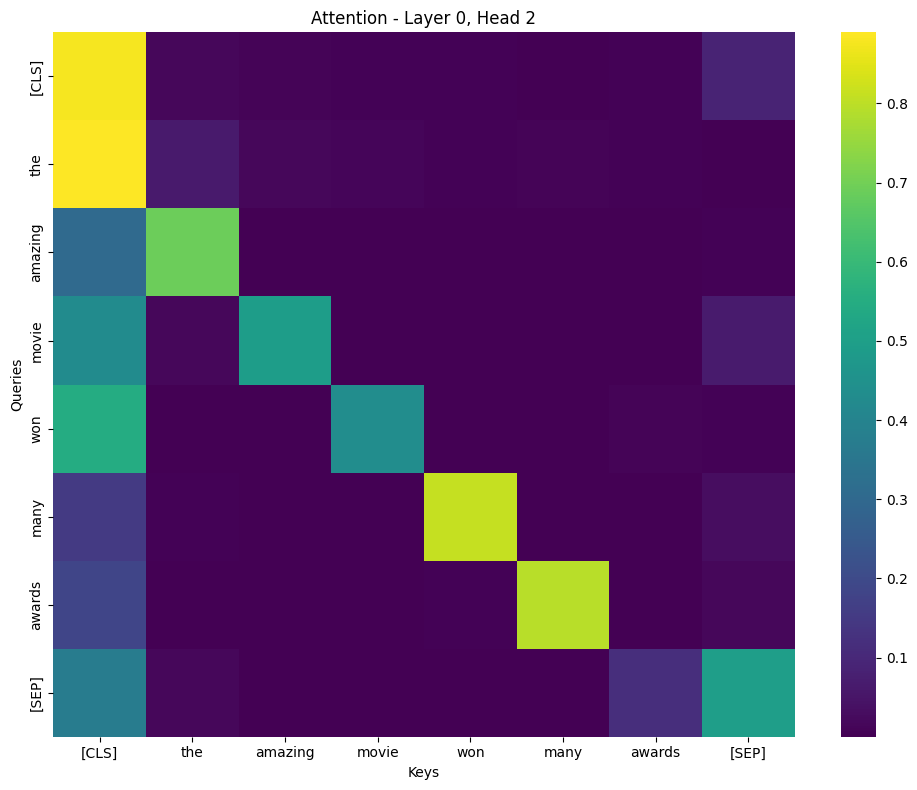

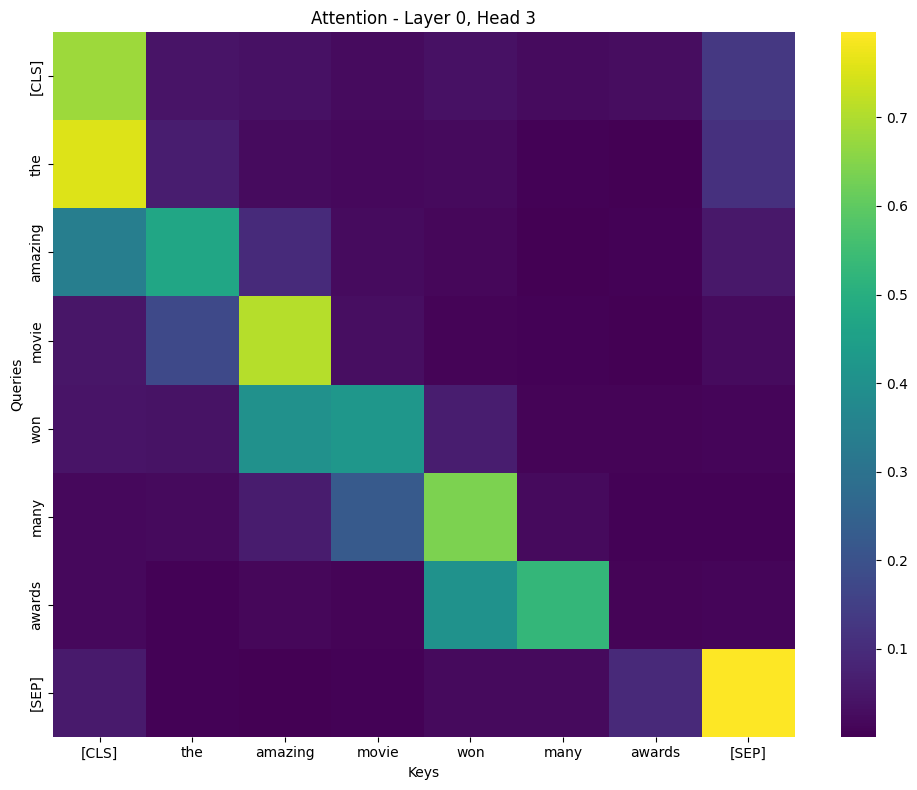

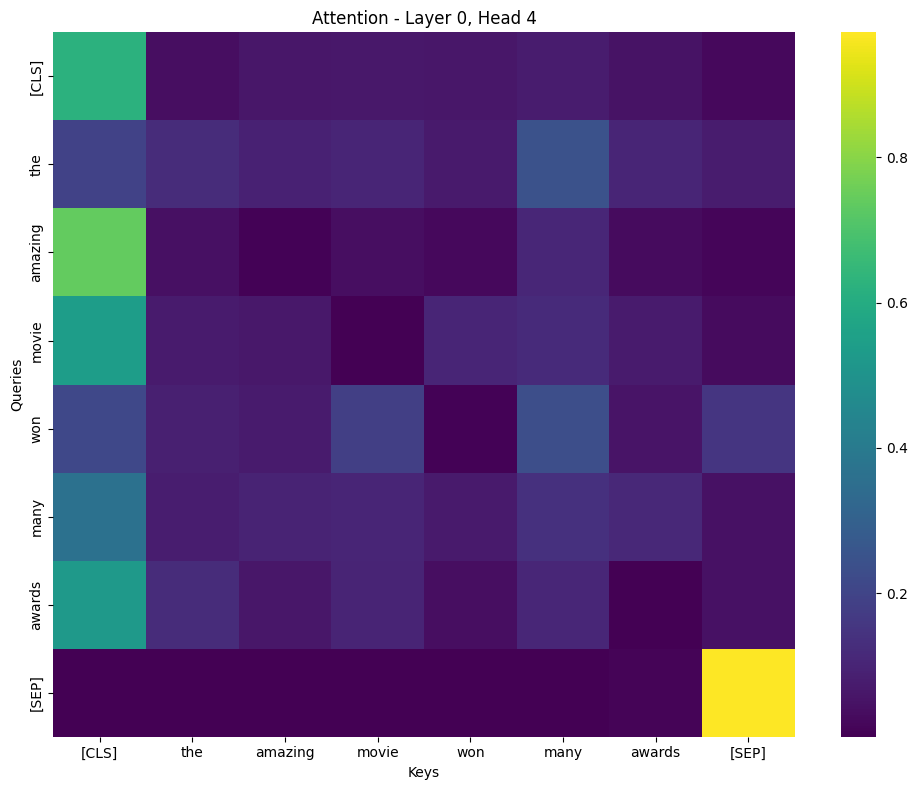

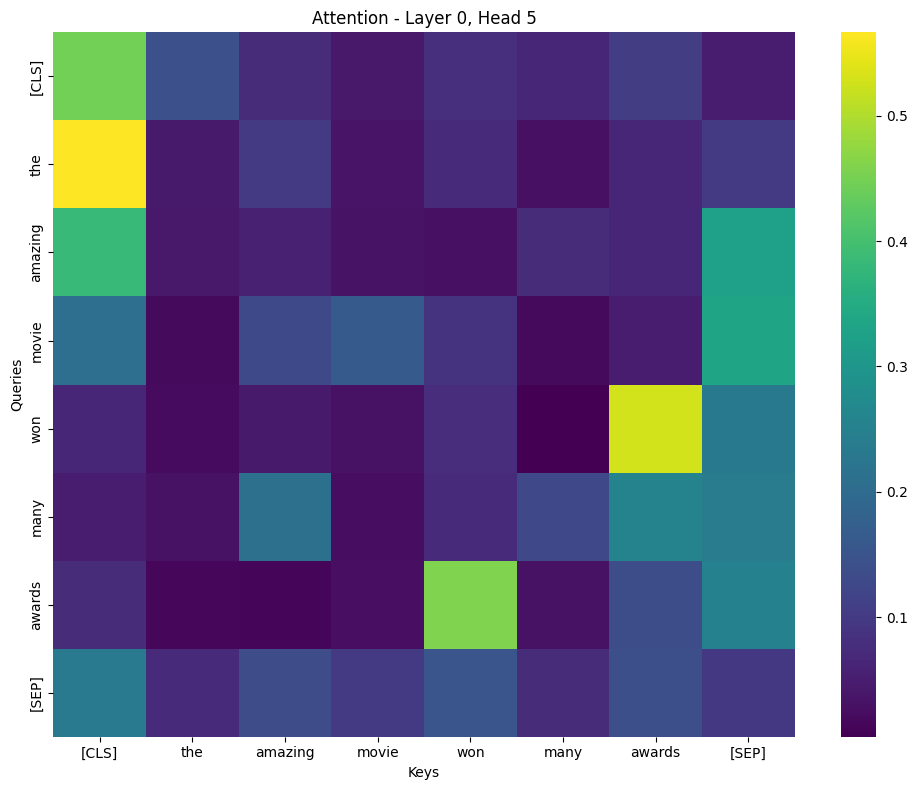

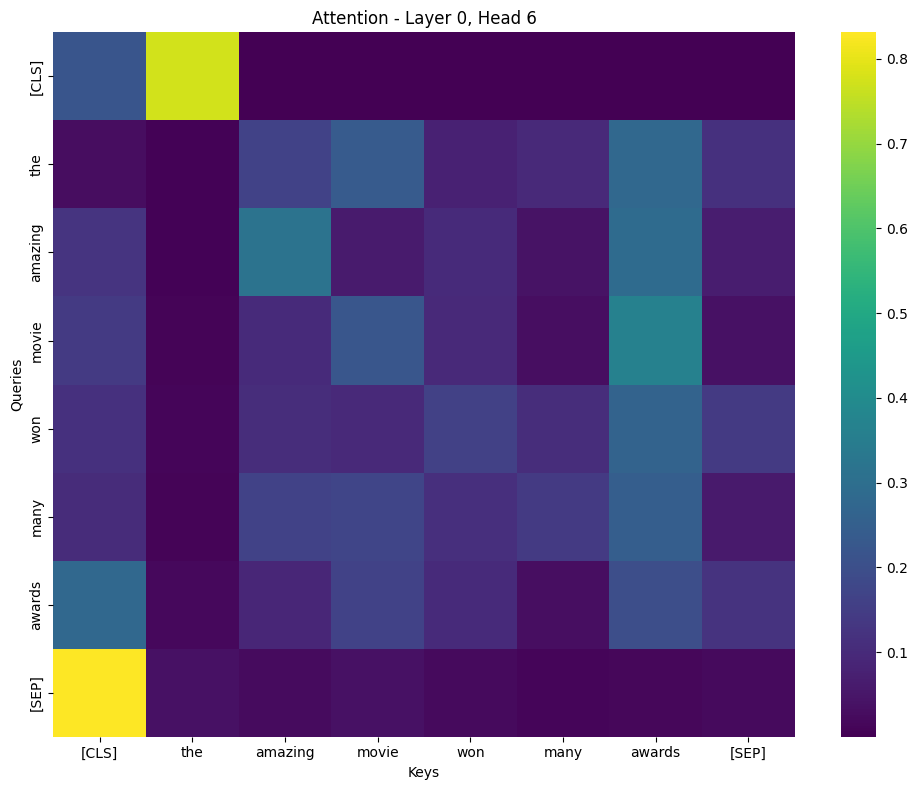

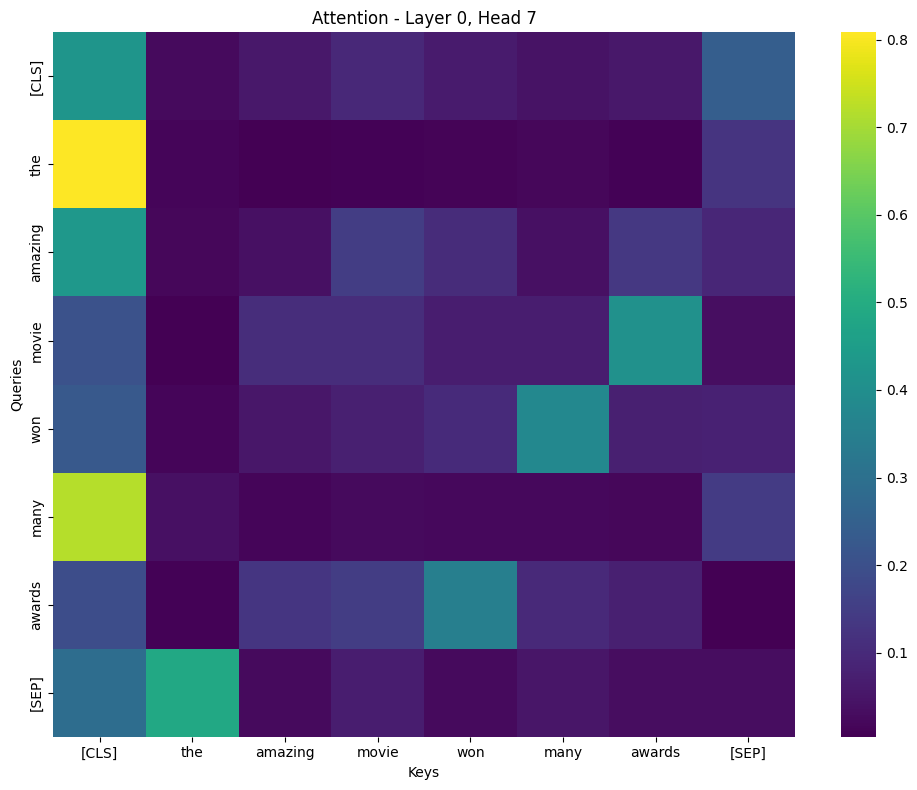

In [ ]:
for head in range(8):  # DistilBERT имеет 8 голов
    visualize_attention(tokens, outputs.attentions, layer=0, head=head)

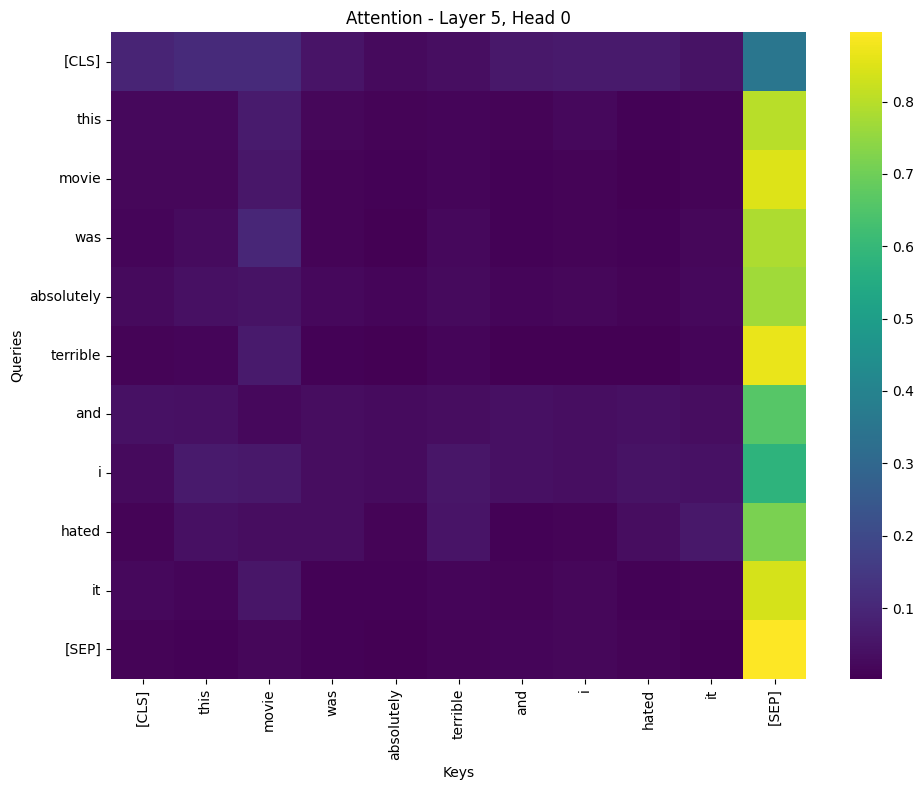

In [ ]:
text = "This movie was absolutely terrible and I hated it"
tokens = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**tokens)

# Визуализируйте
visualize_attention(tokens, outputs.attentions, layer=5, head=0)

In [ ]:
# movie и terrible

### DAY 4

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset
import pandas as pd

try:
    dataset = load_dataset("stanfordnlp/imdb", split="train")
except Exception:
    dataset = load_dataset("imdb", split="train")

df_full = pd.DataFrame(dataset)

df = df_full.sample(1000, random_state=42).reset_index(drop=True)

print(f"Загружено примеров: {len(df)}")
display(df.head())

Загружено примеров: 1000


,text,label
0,"Dumb is as dumb does, in this thoroughly unint...",0
1,I dug out from my garage some old musicals and...,1
2,After watching this movie I was honestly disap...,0
3,This movie was nominated for best picture but ...,1
4,Just like Al Gore shook us up with his painful...,1


In [ ]:
texts = df['text'].tolist()
y = df['label'].tolist()

print(f'Number of texts: {len(texts)}')
print(f'Number of labels: {len(y)}')


Number of texts: 1000
Number of labels: 1000


In [ ]:
X = get_embeddings(texts, tokenizer, model)

print(f'Shape of embeddings (X): {X.shape}')

Shape of embeddings (X): (1000, 768)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train length: {len(y_train)}')
print(f'y_test length: {len(y_test)}')


X_train shape: (800, 768)
X_test shape: (200, 768)
y_train length: 800
y_test length: 200


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(max_iter=1000, n_jobs=-1)

log_reg_model.fit(X_train, y_train)

print('Logistic Regression model trained successfully.')

Logistic Regression model trained successfully.


In [ ]:
from sklearn.metrics import classification_report, f1_score

y_pred = log_reg_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f'Macro F1 Score: {macro_f1:.4f}')

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       102
           1       0.80      0.78      0.79        98

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.80      0.79       200

Macro F1 Score: 0.7947


In [ ]:
with open('baseline_results.txt', 'w') as f:
    f.write("Logistic Regression Baseline Results\n")
    f.write(f"Macro F1 Score: {macro_f1:.4f}\n")
    f.write("\nClassification Report:\n")
    f.write(classification_report(y_test, y_pred))

print("Results saved to baseline_results.txt")

Results saved to baseline_results.txt


In [ ]:
joblib.dump(log_reg_model, 'baseline_model.pkl')



['baseline_model.pkl']

# DAY 5

In [ ]:
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
import pandas as pd

try:
    dataset = load_dataset("stanfordnlp/imdb", split="train")
except Exception:
    dataset = load_dataset("imdb", split="train")

df_full = pd.DataFrame(dataset)

df = df_full.sample(1000, random_state=42).reset_index(drop=True)

print(f"Загружено примеров: {len(df)}")
display(df.head())
texts = df['text'].tolist()
labels = df['label'].tolist()

from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)


Загружено примеров: 1000


,text,label
0,"Dumb is as dumb does, in this thoroughly unint...",0
1,I dug out from my garage some old musicals and...,1
2,After watching this movie I was honestly disap...,0
3,This movie was nominated for best picture but ...,1
4,Just like Al Gore shook us up with his painful...,1


In [ ]:
train_dataset = SentimentDataset(train_texts, train_labels, tokenizer)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer)


In [ ]:
from transformers import AutoModelForSequenceClassification

# Определите количество классов
num_labels = len(set(labels))  # 2 для бинарной, 3 для positive/negative/neutral

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

In [ ]:
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score

optimizer = AdamW(model.parameters(), lr=2e-5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [ ]:
def evaluate(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(outputs.logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')

    return accuracy, f1

In [ ]:
num_epochs = 3

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_acc, val_f1 = evaluate(model, val_loader, device)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f}')
    print(f'Val Accuracy: {val_acc:.4f}')
    print(f'Val F1: {val_f1:.4f}')
    print('-' * 50)

Epoch 1/3
Train Loss: 0.5973
Val Accuracy: 0.8150
Val F1: 0.8148
--------------------------------------------------
Epoch 2/3
Train Loss: 0.3380
Val Accuracy: 0.8150
Val F1: 0.8146
--------------------------------------------------
Epoch 3/3
Train Loss: 0.2041
Val Accuracy: 0.8200
Val F1: 0.8193
--------------------------------------------------


In [ ]:
model.save_pretrained('./fine_tuned_model')
tokenizer.save_pretrained('./fine_tuned_model')

with open('fine_tuned_results.txt', 'w') as f:
    f.write(f'Final Validation F1: {val_f1:.4f}\n')
    f.write(f'Final Validation Accuracy: {val_acc:.4f}\n')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

model_ft = AutoModelForSequenceClassification.from_pretrained('./fine_tuned_model')
tokenizer = AutoTokenizer.from_pretrained('./fine_tuned_model')
model_ft.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
import joblib

baseline_model = joblib.load('baseline_model.pkl')

model_name = "distilbert-base-uncased"
baseline_vectorizer = AutoModel.from_pretrained(model_name)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def predict_fine_tuned(texts, model, tokenizer):
    if isinstance(texts, str):
        texts = [texts]

    predictions = []

    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

        predictions.append({
            'text': text,
            'prediction': pred,
            'probabilities': probs[0].cpu().numpy()
        })

    return predictions

In [115]:
def predict_baseline(texts, model, vectorizer, clean_func=None):
    if isinstance(texts, str):
        texts = [texts]

    if clean_func:
        texts = [clean_func(t) for t in texts]

    X = get_embeddings(texts, tokenizer, vectorizer)

    predictions = model.predict(X)
    probs = model.predict_proba(X) if hasattr(model, 'predict_proba') else None

    results = []
    for i, text in enumerate(texts):
        results.append({
            'text': text,
            'prediction': int(predictions[i]),
            'probabilities': probs[i] if probs is not None else None
        })

    return results

In [116]:
test_texts = [
    "This movie was absolutely fantastic!",
    "Terrible, waste of my time.",
    "It was okay, nothing special.",
    "Best film I've seen this year!",
    "Boring and too long."
]

In [117]:
# Fine-tuned predictions
preds_ft = predict_fine_tuned(test_texts, model_ft, tokenizer)

preds_baseline = predict_baseline(test_texts, baseline_model, baseline_vectorizer)

In [118]:
for i, text in enumerate(test_texts):
    print(f'\nТекст: {text}')
    print(f'Fine-tuned: {preds_ft[i]["prediction"]} (probs: {preds_ft[i]["probabilities"]})')
    if baseline_model:
        print(f'Baseline: {preds_baseline[i]["prediction"]}')
        print(f'Совпадают: {preds_ft[i]["prediction"] == preds_baseline[i]["prediction"]}')


Текст: This movie was absolutely fantastic!
Fine-tuned: 1 (probs: [0.03057596 0.969424  ])
Baseline: 1
Совпадают: True

Текст: Terrible, waste of my time.
Fine-tuned: 0 (probs: [0.9547862  0.04521383])
Baseline: 1
Совпадают: False

Текст: It was okay, nothing special.
Fine-tuned: 1 (probs: [0.3009546  0.69904536])
Baseline: 1
Совпадают: True

Текст: Best film I've seen this year!
Fine-tuned: 1 (probs: [0.12848452 0.87151545])
Baseline: 1
Совпадают: True

Текст: Boring and too long.
Fine-tuned: 0 (probs: [0.9422265  0.05777343])
Baseline: 0
Совпадают: True


In [142]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.DataFrame(load_dataset("stanfordnlp/imdb", split="train")).sample(1000, random_state = 42)
_, test_df, _, _ = train_test_split(df, df['label'], test_size=0.2, random_state=42, stratify=df['label'])

In [143]:
test_texts = test_df['text'].tolist()
test_labels = test_df['label'].tolist()

In [144]:
preds_ft_all = predict_fine_tuned(test_texts, model_ft, tokenizer)
y_pred_ft = [p['prediction'] for p in preds_ft_all]

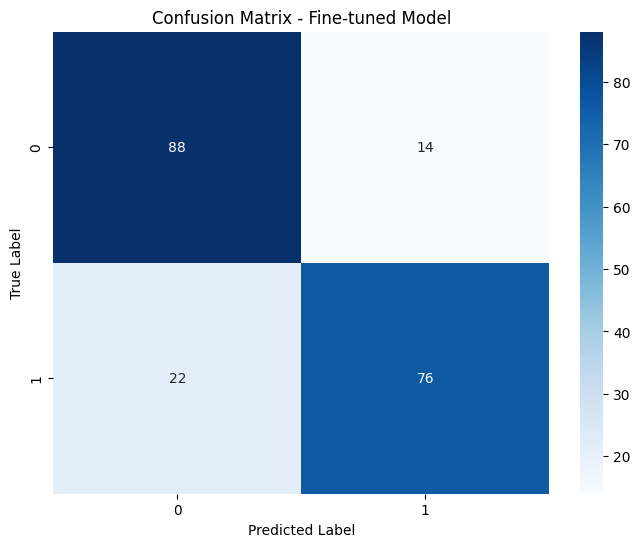

In [145]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_ft = confusion_matrix(test_labels, y_pred_ft)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Fine-tuned Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix_finetuned.png')

In [146]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

print("=== Fine-tuned Model ===")
print(classification_report(test_labels, y_pred_ft))
f1_ft = f1_score(test_labels, y_pred_ft, average='macro')
acc_ft = accuracy_score(test_labels, y_pred_ft)

if baseline_model:
    preds_baseline_all = predict_baseline(test_texts, baseline_model, baseline_vectorizer)
    y_pred_base = [p['prediction'] for p in preds_baseline_all]

    print("\n=== Baseline Model ===")
    print(classification_report(test_labels, y_pred_base))
    f1_base = f1_score(test_labels, y_pred_base, average='macro')
    acc_base = accuracy_score(test_labels, y_pred_base)

    print(f'\n=== Сравнение ===')
    print(f'Fine-tuned F1: {f1_ft:.4f}, Accuracy: {acc_ft:.4f}')
    print(f'Baseline F1: {f1_base:.4f}, Accuracy: {acc_base:.4f}')
    print(f'Улучшение F1: {(f1_ft - f1_base) / f1_base * 100:.2f}%')

=== Fine-tuned Model ===
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       102
           1       0.84      0.78      0.81        98

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200


=== Baseline Model ===
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       102
           1       0.80      0.78      0.79        98

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.80      0.79       200


=== Сравнение ===
Fine-tuned F1: 0.8193, Accuracy: 0.8200
Baseline F1: 0.7947, Accuracy: 0.7950
Улучшение F1: 3.10%


In [147]:
with open('comparison_results.txt', 'w') as f:
    f.write('=== Сравнение моделей ===\n\n')
    f.write(f'Fine-tuned Model:\n')
    f.write(f'  F1 (macro): {f1_ft:.4f}\n')
    f.write(f'  Accuracy: {acc_ft:.4f}\n')

    if baseline_model:
        f.write(f'\nBaseline Model:\n')
        f.write(f'  F1 (macro): {f1_base:.4f}\n')
        f.write(f'  Accuracy: {acc_base:.4f}\n')
        f.write(f'\nУлучшение: {(f1_ft - f1_base) / f1_base * 100:.2f}%\n')

# DAY 7

In [148]:
import pandas as pd

# Загрузите данные и предсказания из Дня 6
df_test = pd.DataFrame({
    'text': test_texts,
    'true_label': test_labels,
    'pred_label': y_pred_ft
})

# Найдите ошибки
errors = df_test[df_test['true_label'] != df_test['pred_label']]

# False Positives (предсказала positive, а было negative/neutral)
fp = errors[(errors['pred_label'] == 1) & (errors['true_label'] == 0)]

# False Negatives (предсказала negative, а было positive)
fn = errors[(errors['pred_label'] == 0) & (errors['true_label'] == 1)]

print(f'Всего ошибок: {len(errors)}')
print(f'False Positives: {len(fp)}')
print(f'False Negatives: {len(fn)}')

Всего ошибок: 36
False Positives: 14
False Negatives: 22


In [149]:
print("\n=== FALSE POSITIVES (сказали good, а было bad) ===")
for idx, row in fp.head(5).iterrows():
    print(f'\nТекст: {row["text"][:100]}...')
    print(f'Истинный класс: {row["true_label"]}, Предсказан: {row["pred_label"]}')

print("\n=== FALSE NEGATIVES (сказали bad, а было good) ===")
for idx, row in fn.head(5).iterrows():
    print(f'\nТекст: {row["text"][:100]}...')
    print(f'Истинный класс: {row["true_label"]}, Предсказан: {row["pred_label"]}')


=== FALSE POSITIVES (сказали good, а было bad) ===

Текст: A broke would be screenwriter and his would be agent (Tom Wood and Arye Gross) are forced to live in...
Истинный класс: 0, Предсказан: 1

Текст: This movie is an abomination, and its making should have been considered a capital crime.<br /><br /...
Истинный класс: 0, Предсказан: 1

Текст: When Sam Peckinpah's superlative THE WILD BUNCH (1969) opened the door to outrageous displays of gra...
Истинный класс: 0, Предсказан: 1

Текст: Hubert Selby Jr. gave us the book "Requiem For A Dream" and co-wrote the screenplay to Aronofsky's m...
Истинный класс: 0, Предсказан: 1

Текст: I'm the sort of person who went down to the local library and read books on Babbage's difference eng...
Истинный класс: 0, Предсказан: 1

=== FALSE NEGATIVES (сказали bad, а было good) ===

Текст: A film that can make you shed tears of sadness and tears of joy would be considered quite a step in ...
Истинный класс: 1, Предсказан: 0

Текст: This flick is ster

In [150]:
errors['text_length'] = errors['text'].str.len()
print(f'\nСредняя длина ошибочных текстов: {errors["text_length"].mean():.0f}')
print(f'Средняя длина всех текстов: {df_test["text"].str.len().mean():.0f}')


Средняя длина ошибочных текстов: 1716
Средняя длина всех текстов: 1376


/tmp/ipykernel_620/2375809873.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['text_length'] = errors['text'].str.len()


In [151]:
with open('error_analysis.txt', 'w') as f:
    f.write('=== АНАЛИЗ ОШИБОК ===\n\n')
    f.write(f'Всего ошибок: {len(errors)}\n')
    f.write(f'False Positives: {len(fp)}\n')
    f.write(f'False Negatives: {len(fn)}\n\n')

    f.write('=== ПРИМЕРЫ FALSE POSITIVES ===\n')
    for idx, row in fp.head(5).iterrows():
        f.write(f'\nТекст: {row["text"]}\n')
        f.write(f'Истинный: {row["true_label"]}, Предсказан: {row["pred_label"]}\n')

    f.write('\n\n=== ПРИМЕРЫ FALSE NEGATIVES ===\n')
    for idx, row in fn.head(5).iterrows():
        f.write(f'\nТекст: {row["text"]}\n')
        f.write(f'Истинный: {row["true_label"]}, Предсказан: {row["pred_label"]}\n')

    f.write('\n\n=== НАБЛЮДЕНИЯ ===\n')
    f.write('Добавьте сюда ваши выводы о паттернах ошибок...\n')

In [152]:
pip install fastapi uvicorn

In [154]:
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()

class PredictionRequest(BaseModel):
    text: str

@app.post("/predict")
def predict(request: PredictionRequest):
    inputs = tokenizer(request.text, return_tensors="pt", truncation=True, max_length=128)

    with torch.no_grad():
        outputs = model_ft(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()

    label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

    return {
        "prediction": label_map.get(pred, str(pred)),
        "probabilities": {
            label_map.get(i, str(i)): float(probs[0][i])
            for i in range(len(probs[0]))
        }
    }

In [155]:
!uvicorn api:app --reload

INFO:     Will watch for changes in these directories: ['/content']
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     Started reloader process [10203] using WatchFiles
ERROR:    Error loading ASGI app. Could not import module "api".
INFO:     Stopping reloader process [10203]
